# Quantum Convolutional Neural Network (QCNN) Training on COCO Dataset

This notebook demonstrates training a QCNN model on the COCO dataset. The QCNN architecture combines quantum convolutional and pooling operations, inspired by classical CNNs.

In [29]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Silence INFO and WARNING messages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import tensorflow as tf
import pennylane as qml
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Import our custom models and utils
import sys
sys.path.append('../src')
from models.qcnn import QCNNModel
from utils.rbs_gate import *
from utils.pruning import ScheduledGradientPruning

## 1. Data Loading and Preprocessing

Load and preprocess the COCO dataset images for training.

In [30]:
def load_coco_data(data_dir='../data/test2017', 
                   annotation_file='../data/annotations/image_info_test2017.json',
                   img_size=(32, 32)):
    """
    Load COCO dataset images using a JSON file that connects images to categories via the license field.
    Here we assume that each image's "license" field is a category id and that the corresponding
    category's "supercategory" is used as the annotation (label).

    Args:
        data_dir (str): Directory containing image files.
        annotation_file (str): Path to the JSON file with image info.
        img_size (tuple): Target size (height, width) for image resizing.
    
    Returns:
        images (np.array): Array of preprocessed images.
        labels (np.array): Array of corresponding binary labels (float 0.0 or 1.0).
    """
    # Load the JSON file
    with open(annotation_file, 'r') as f:
        coco_data = json.load(f)
    print("Number of images in annotation:", len(coco_data.get('images', [])))
    print("Number of categories in annotation:", len(coco_data.get('categories', [])))

    # Extract image info and categories
    images_info = coco_data.get('images', [])
    categories = coco_data.get('categories', [])
    
    # Create a mapping from category id to its supercategory (annotation)
    # Note: This mapping is built from the "categories" field.
    cat_map = {cat['id']: cat['supercategory'] for cat in categories}
    
    images = []
    labels = []
    
    # Define your binary mapping here.
    binary_map = {
        "person": 0.0,
        "vehicle": 1.0
    }
    
    # Process each image in the JSON
    for img_info in tqdm(images_info, desc='Loading images'):
        file_name = img_info.get('file_name')
        license_id = img_info.get('license')
        
        # Use license_id to get the label from cat_map
        label_str = cat_map.get(license_id)
        if label_str is None:
            # Skip image if no corresponding category found
            continue
        
        # Convert string label to binary float.
        # If the label is not in binary_map, skip the image.
        if label_str not in binary_map:
            continue
        label = binary_map[label_str]
        
        img_path = os.path.join(data_dir, file_name)
        if not os.path.exists(img_path):
            print(f"Image file not found: {img_path}")
            continue
        
        try:
            # Load and preprocess the image
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = img_array / 255.0  # Normalize to [0,1]
            images.append(img_array)
            labels.append(label)
        except Exception as e:
            print(f"Error processing image {img_path}: {e}")
            continue

    images = np.array(images)
    labels = np.array(labels, dtype=np.float32)
    print(f"Successfully loaded {len(images)} images with labels.")
    return images, labels

# Load data
X, y = load_coco_data()

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TensorFlow datasets
batch_size = 32  # Smaller batch size for quantum computation
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

Loading images:   3%|▎         | 15/500 [00:00<00:03, 145.98it/s]

Loading images: 100%|██████████| 500/500 [00:03<00:00, 144.00it/s]


## 2. Create QCNN Model

Initialize the QCNN model with or without pruning enhancement.

In [31]:
# Model configuration parameters
random_seed = 42
n_qubits = 6
n_layers = 2
embedding_type = 'angle'

# Choose whether to use pruning
use_pruning = True

if use_pruning:
    algorithm = 'pruning'
    algorithm_params = {
        'accumulate_window': 50,   # Number of steps to accumulate gradients
        'prune_window': 100,       # Number of steps between pruning operations
        'prune_ratio': 0.3,        # Ratio of weights to prune
        'schedule': True           # Use scheduled pruning
    }
else:
    algorithm = None
    algorithm_params = None

# Create the QCNN model
model = QCNNModel(
    random_seed=random_seed,
    algorithm=algorithm,
    algorithm_params=algorithm_params,
    n_qubits=n_qubits,
    n_layers=n_layers,
    embedding_type=embedding_type
)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 3. Training Loop

Train the QCNN model with appropriate callbacks.

In [32]:
# Create a callback to monitor pruning (if used)
class PruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, model):
        super(PruningCallback, self).__init__()
        self.model = model
        self.pruning_history = []
    
    def on_epoch_end(self, epoch, logs=None):
        if hasattr(self.model, 'algorithm') and self.model.algorithm is not None:
            try:
                pruning_stats = self.model.algorithm.get_pruning_stats()
                self.pruning_history.append(pruning_stats)
                print(f"Epoch {epoch + 1} Pruning Stats:")
                print(f"  - Phase: {pruning_stats['phase']}")
                print(f"  - Pruning Ratio: {pruning_stats['current_ratio']:.3f}")
                print(f"  - Pruned Weights: {pruning_stats['num_pruned']}/{pruning_stats['total_weights']}")
            except Exception as e:
                print(f"Warning: Could not get pruning stats: {str(e)}")

# Set up training parameters
epochs = 100
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)
]

# Add pruning callback if using pruning
if use_pruning:
    pruning_callback = PruningCallback(model)
    callbacks.append(pruning_callback)

# Train the model
history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=test_dataset,
    callbacks=callbacks
)

Epoch 1/100


25/25 [==============================] - ETA: 0s - loss: 0.7236 - accuracy: 0.4600Epoch 1 Pruning Stats:
  - Phase: accumulate
  - Pruning Ratio: 0.300
  - Pruned Weights: 8/27
25/25 [==============================] - 34s 427ms/step - loss: 0.7236 - accuracy: 0.4600 - val_loss: 0.6941 - val_accuracy: 0.4800
Epoch 2/100
25/25 [==============================] - ETA: 0s - loss: 0.6971 - accuracy: 0.4575Epoch 2 Pruning Stats:
  - Phase: accumulate
  - Pruning Ratio: 0.300
  - Pruned Weights: 8/27
25/25 [==============================] - 4s 148ms/step - loss: 0.6971 - accuracy: 0.4575 - val_loss: 0.6980 - val_accuracy: 0.4700
Epoch 3/100
25/25 [==============================] - ETA: 0s - loss: 0.6970 - accuracy: 0.4975Epoch 3 Pruning Stats:
  - Phase: prune
  - Pruning Ratio: 0.495
  - Pruned Weights: 13/27
25/25 [==============================] - 3s 137ms/step - loss: 0.6970 - accuracy: 0.4975 - val_loss: 0.6966 - val_accuracy: 0.4900
Epoch 4/100
25/25 [==============================] - ET

## 4. Visualization and Analysis

Visualize training metrics and QCNN performance.

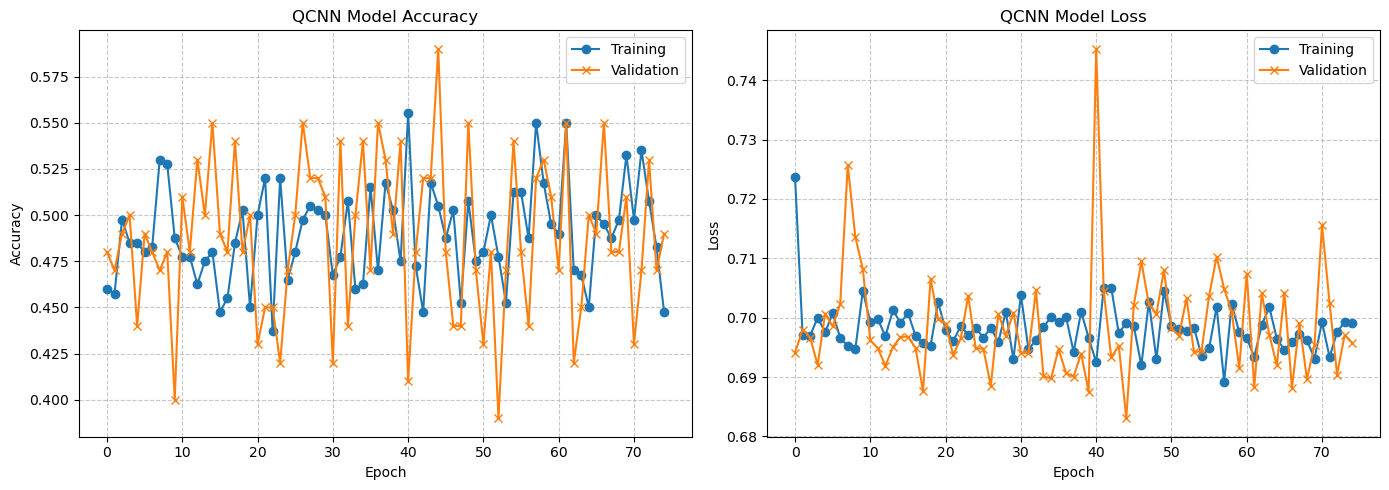

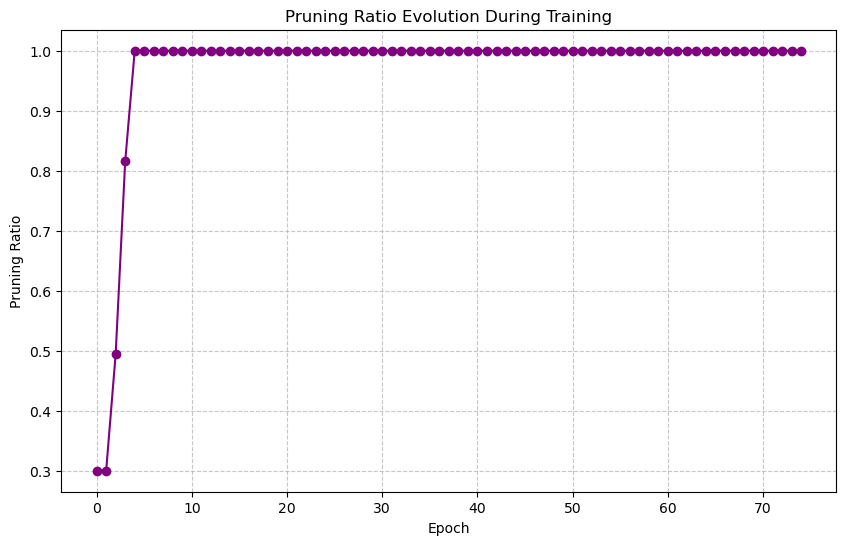

In [33]:
# Plot training history
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training', marker='o')
    ax1.plot(history.history['val_accuracy'], label='Validation', marker='x')
    ax1.set_title('QCNN Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.legend()
    
    # Plot loss
    ax2.plot(history.history['loss'], label='Training', marker='o')
    ax2.plot(history.history['val_loss'], label='Validation', marker='x')
    ax2.set_title('QCNN Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.grid(True, linestyle='--', alpha=0.7)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Plot pruning history if available
def plot_pruning_history(callback):
    if not hasattr(callback, 'pruning_history') or not callback.pruning_history:
        print("No pruning history available")
        return
    
    pruning_ratios = [stats['current_ratio'] for stats in callback.pruning_history]
    
    plt.figure(figsize=(10, 6))
    plt.plot(pruning_ratios, marker='o', linestyle='-', color='purple')
    plt.title('Pruning Ratio Evolution During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Pruning Ratio')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# Plot training history
plot_training_history(history)

# Plot pruning history if available
if use_pruning:
    plot_pruning_history(pruning_callback)

## 5. QCNN Evaluation

Evaluate the QCNN model on the test set.

7/7 [==============================] - 0s 21ms/step - loss: 0.6831 - accuracy: 0.5900

Test accuracy: 0.5900

Number of quantum weights: 27


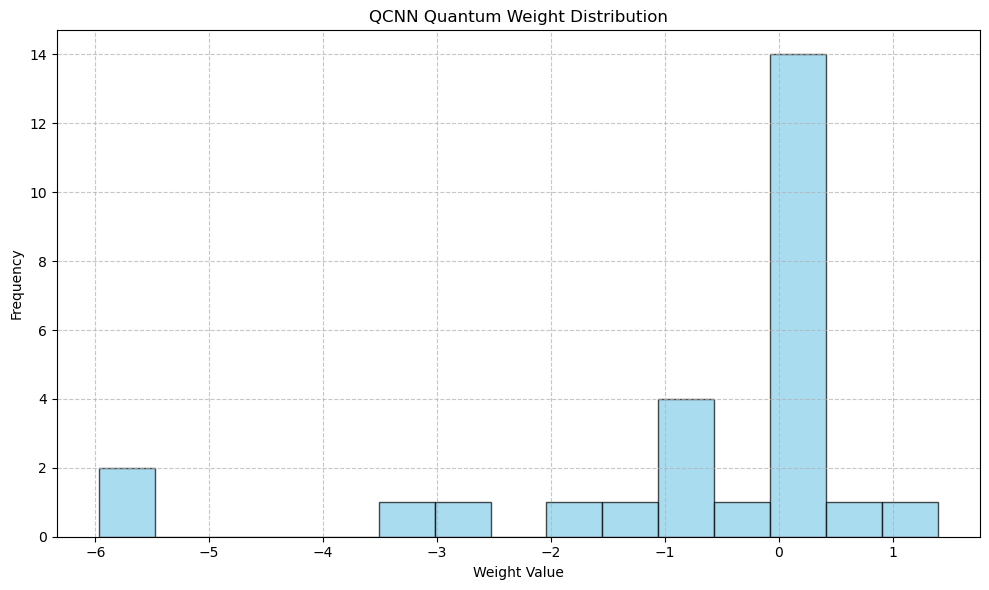

In [34]:
# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"\nTest accuracy: {test_accuracy:.4f}")

# Print final quantum weights
quantum_weights = model.quantum_weights.numpy()
print(f"\nNumber of quantum weights: {len(quantum_weights)}")

# Visualize quantum weight distribution
plt.figure(figsize=(10, 6))
plt.hist(quantum_weights, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('QCNN Quantum Weight Distribution')
plt.xlabel('Weight Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Additional Analysis

Analyze model predictions and perform additional evaluations.

7/7 [==============================] - 7s 22ms/step


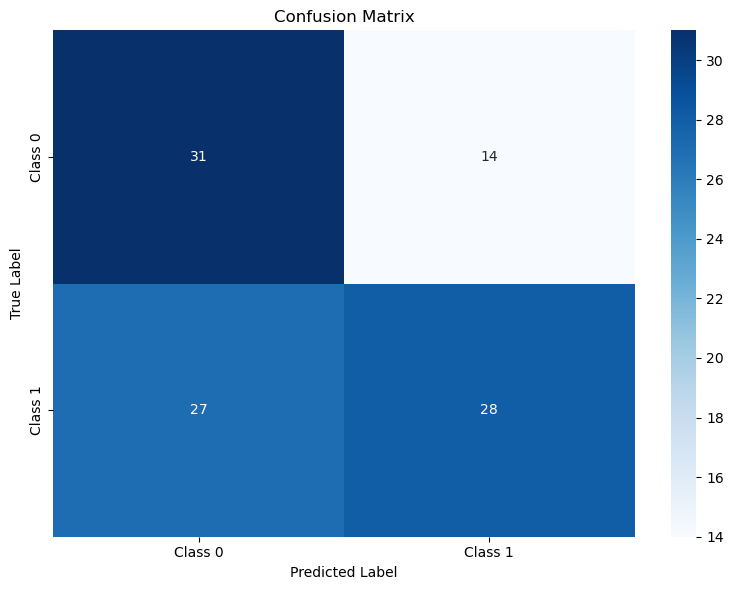

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.69      0.60        45
           1       0.67      0.51      0.58        55

    accuracy                           0.59       100
   macro avg       0.60      0.60      0.59       100
weighted avg       0.61      0.59      0.59       100



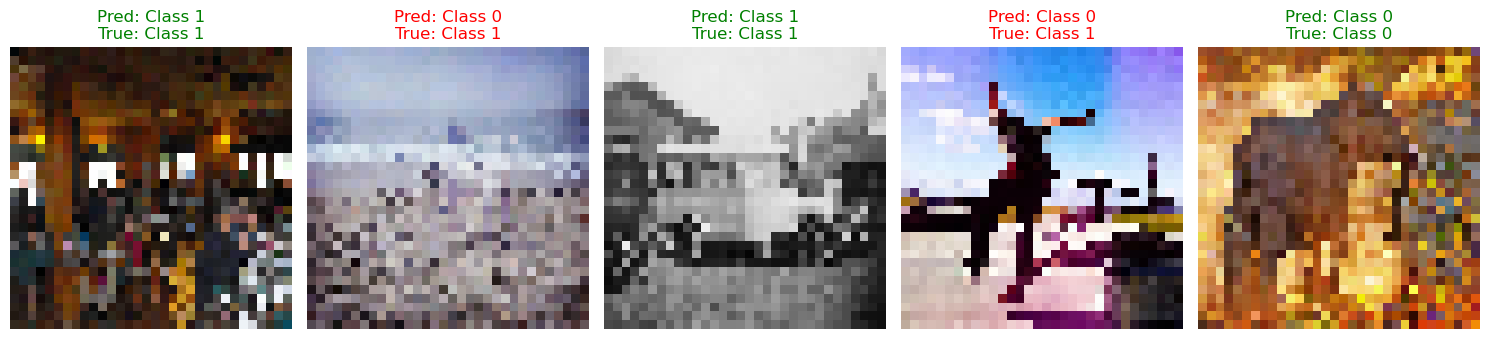

In [35]:
# Get predictions on test data
y_pred = model.predict(test_dataset)
y_pred_binary = (y_pred > 0.5).astype(int).flatten()

# Calculate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_binary)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_binary))

# Visualize some predictions
def display_prediction_examples(X, y_true, y_pred, num_examples=5):
    # Randomly select examples
    indices = np.random.choice(range(len(y_true)), num_examples, replace=False)
    
    fig, axes = plt.subplots(1, num_examples, figsize=(15, 4))
    
    for i, idx in enumerate(indices):
        axes[i].imshow(X[idx])
        prediction = 'Class 1' if y_pred[idx] > 0.5 else 'Class 0'
        actual = 'Class 1' if y_true[idx] == 1 else 'Class 0'
        color = 'green' if (y_pred[idx] > 0.5) == y_true[idx] else 'red'
        
        axes[i].set_title(f"Pred: {prediction}\nTrue: {actual}", color=color)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
display_prediction_examples(X_test, y_test, y_pred)